# **Data Loading and Visualization**

## Import packages

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Initialize theme and set Path of data

In [25]:
#init theme and get path 

sns.set_theme(style="whitegrid")

path = Path("../data/activities.csv")

## Load Data and get shape/Info on csv file from Strava

In [26]:
#load data

df = pd.read_csv(path)

print("Shape:", df.shape)
df.head()

Shape: (83, 101)


,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,Timer Time,Total Cycles,Recovery,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Media
0,13458414210,"Jan 15, 2025, 9:19:42 PM",Afternoon Squash,Workout,NaN,2758,0.00,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13458414298,"Jan 24, 2025, 5:24:29 PM",Lunch Run,Run,NaN,1160,3.31,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13512206335,"Feb 1, 2025, 4:26:38 PM",Morning Run,Run,NaN,3711,8.04,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13584883390,"Feb 9, 2025, 5:31:46 PM",Lunch Run,Run,NaN,1711,4.86,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15068666695,"Jul 8, 2025, 11:41:14 AM",Morning Weight Training,Weight Training,NaN,3440,0.00,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
#get column info
print(df.columns.tolist())

['Activity ID', 'Activity Date', 'Activity Name', 'Activity Type', 'Activity Description', 'Elapsed Time', 'Distance', 'Max Heart Rate', 'Relative Effort', 'Commute', 'Activity Private Note', 'Activity Gear', 'Filename', 'Athlete Weight', 'Bike Weight', 'Elapsed Time.1', 'Moving Time', 'Distance.1', 'Max Speed', 'Average Speed', 'Elevation Gain', 'Elevation Loss', 'Elevation Low', 'Elevation High', 'Max Grade', 'Average Grade', 'Average Positive Grade', 'Average Negative Grade', 'Max Cadence', 'Average Cadence', 'Max Heart Rate.1', 'Average Heart Rate', 'Max Watts', 'Average Watts', 'Calories', 'Max Temperature', 'Average Temperature', 'Relative Effort.1', 'Total Work', 'Number of Runs', 'Uphill Time', 'Downhill Time', 'Other Time', 'Perceived Exertion', 'Type', 'Start Time', 'Weighted Average Power', 'Power Count', 'Prefer Perceived Exertion', 'Perceived Relative Effort', 'Commute.1', 'Total Weight Lifted', 'From Upload', 'Grade Adjusted Distance', 'Weather Observation Time', 'Weather

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Columns: 101 entries, Activity ID to Media
dtypes: bool(1), float64(92), int64(2), str(6)
memory usage: 65.1 KB


## Create a filter on data to get run Data only

In [29]:
runs = df[df["Activity Type"] == "Run"].copy()

print("Total runs: ", len(runs))
runs.head()

Total runs:  24


,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,Timer Time,Total Cycles,Recovery,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Media
1,13458414298,"Jan 24, 2025, 5:24:29 PM",Lunch Run,Run,NaN,1160,3.31,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13512206335,"Feb 1, 2025, 4:26:38 PM",Morning Run,Run,NaN,3711,8.04,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13584883390,"Feb 9, 2025, 5:31:46 PM",Lunch Run,Run,NaN,1711,4.86,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,15074546661,"Jul 11, 2025, 1:16:19 AM",Evening Run,Run,NaN,1201,3.23,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,15451190696,"Aug 13, 2025, 11:16:22 AM",Morning Run,Run,NaN,1253,3.25,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Select the relevant Columns to runs

In [30]:
cols = [
    "Activity Date",
    "Activity Name",
    "Activity Type",
    "Distance",
    "Moving Time",
    "Elapsed Time",
    "Average Speed",
    "Max Speed",
    "Elevation Gain",
    "Elevation Loss",
    "Average Grade",
    "Max Grade",
    "Average Heart Rate",
    "Max Heart Rate",
    "Relative Effort",
    "Perceived Exertion",
    "Training Load",
    "Intensity",
    "Weather Temperature",
    "Humidity",
    "Wind Speed",
    "Commute",
    "Long Run",
    "Competition"
]

available_cols = [c for c in cols if c in runs.columns]

runs = runs[available_cols].copy()

runs.head()

,Activity Date,Activity Name,Activity Type,Distance,Moving Time,Elapsed Time,Average Speed,Max Speed,Elevation Gain,Elevation Loss,...,Relative Effort,Perceived Exertion,Training Load,Intensity,Weather Temperature,Humidity,Wind Speed,Commute,Long Run,Competition
1,"Jan 24, 2025, 5:24:29 PM",Lunch Run,Run,3.31,1051.0,1160,3.157,5.020,27.2,43.6,...,NaN,NaN,79.0,157.0,NaN,NaN,NaN,False,NaN,NaN
2,"Feb 1, 2025, 4:26:38 PM",Morning Run,Run,8.04,2950.0,3711,2.728,8.241,74.8,78.4,...,NaN,NaN,227.0,151.0,NaN,NaN,NaN,False,NaN,NaN
3,"Feb 9, 2025, 5:31:46 PM",Lunch Run,Run,4.86,1658.0,1711,2.936,4.838,27.6,64.0,...,NaN,NaN,119.0,159.0,NaN,NaN,NaN,False,NaN,NaN
8,"Jul 11, 2025, 1:16:19 AM",Evening Run,Run,3.23,1102.0,1201,2.934,4.800,20.4,18.4,...,NaN,NaN,72.0,147.0,NaN,NaN,NaN,False,NaN,NaN
15,"Aug 13, 2025, 11:16:22 AM",Morning Run,Run,3.25,1180.0,1253,2.758,4.740,21.2,19.2,...,NaN,NaN,73.0,145.0,25.0,0.81,0.9,False,NaN,NaN


## Rename columns for easier df work

In [31]:
runs = runs.rename(columns={
    "Activity Date": "date",
    "Distance": "distance_m",
    "Moving Time": "moving_time_s",
    "Elapsed Time": "elapsed_time_s",
    "Average Heart Rate": "avg_hr",
    "Max Heart Rate": "max_hr",
    "Elevation Gain": "elev_gain",
    "Elevation Loss": "elev_loss",
    "Average Speed": "avg_speed",
    "Max Speed": "max_speed"
})

runs.head()

,date,Activity Name,Activity Type,distance_m,moving_time_s,elapsed_time_s,avg_speed,max_speed,elev_gain,elev_loss,...,Relative Effort,Perceived Exertion,Training Load,Intensity,Weather Temperature,Humidity,Wind Speed,Commute,Long Run,Competition
1,"Jan 24, 2025, 5:24:29 PM",Lunch Run,Run,3.31,1051.0,1160,3.157,5.020,27.2,43.6,...,NaN,NaN,79.0,157.0,NaN,NaN,NaN,False,NaN,NaN
2,"Feb 1, 2025, 4:26:38 PM",Morning Run,Run,8.04,2950.0,3711,2.728,8.241,74.8,78.4,...,NaN,NaN,227.0,151.0,NaN,NaN,NaN,False,NaN,NaN
3,"Feb 9, 2025, 5:31:46 PM",Lunch Run,Run,4.86,1658.0,1711,2.936,4.838,27.6,64.0,...,NaN,NaN,119.0,159.0,NaN,NaN,NaN,False,NaN,NaN
8,"Jul 11, 2025, 1:16:19 AM",Evening Run,Run,3.23,1102.0,1201,2.934,4.800,20.4,18.4,...,NaN,NaN,72.0,147.0,NaN,NaN,NaN,False,NaN,NaN
15,"Aug 13, 2025, 11:16:22 AM",Morning Run,Run,3.25,1180.0,1253,2.758,4.740,21.2,19.2,...,NaN,NaN,73.0,145.0,25.0,0.81,0.9,False,NaN,NaN


In [32]:
runs["date"] = pd.to_datetime(runs["date"])

runs = runs.sort_values("date")

runs.head()

/var/folders/3r/_yrwnf8n02l1yblk6m35hprc0000gn/T/ipykernel_1614/866161522.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  runs["date"] = pd.to_datetime(runs["date"])


,date,Activity Name,Activity Type,distance_m,moving_time_s,elapsed_time_s,avg_speed,max_speed,elev_gain,elev_loss,...,Relative Effort,Perceived Exertion,Training Load,Intensity,Weather Temperature,Humidity,Wind Speed,Commute,Long Run,Competition
1,2025-01-24 17:24:29,Lunch Run,Run,3.31,1051.0,1160,3.157,5.020,27.2,43.6,...,NaN,NaN,79.0,157.0,NaN,NaN,NaN,False,NaN,NaN
2,2025-02-01 16:26:38,Morning Run,Run,8.04,2950.0,3711,2.728,8.241,74.8,78.4,...,NaN,NaN,227.0,151.0,NaN,NaN,NaN,False,NaN,NaN
3,2025-02-09 17:31:46,Lunch Run,Run,4.86,1658.0,1711,2.936,4.838,27.6,64.0,...,NaN,NaN,119.0,159.0,NaN,NaN,NaN,False,NaN,NaN
8,2025-07-11 01:16:19,Evening Run,Run,3.23,1102.0,1201,2.934,4.800,20.4,18.4,...,NaN,NaN,72.0,147.0,NaN,NaN,NaN,False,NaN,NaN
15,2025-08-13 11:16:22,Morning Run,Run,3.25,1180.0,1253,2.758,4.740,21.2,19.2,...,NaN,NaN,73.0,145.0,25.0,0.81,0.9,False,NaN,NaN


## Unit Conversions

In [33]:
runs["distance_miles"] = runs["distance_m"] * 0.621371
runs["time_min"] = runs["moving_time_s"] / 60

runs["pace_min_per_mile"] = runs["time_min"] / runs["distance_miles"]

runs.head()

,date,Activity Name,Activity Type,distance_m,moving_time_s,elapsed_time_s,avg_speed,max_speed,elev_gain,elev_loss,...,Intensity,Weather Temperature,Humidity,Wind Speed,Commute,Long Run,Competition,distance_miles,time_min,pace_min_per_mile
1,2025-01-24 17:24:29,Lunch Run,Run,3.31,1051.0,1160,3.157,5.020,27.2,43.6,...,157.0,NaN,NaN,NaN,False,NaN,NaN,2.056738,17.516667,8.516722
2,2025-02-01 16:26:38,Morning Run,Run,8.04,2950.0,3711,2.728,8.241,74.8,78.4,...,151.0,NaN,NaN,NaN,False,NaN,NaN,4.995823,49.166667,9.841555
3,2025-02-09 17:31:46,Lunch Run,Run,4.86,1658.0,1711,2.936,4.838,27.6,64.0,...,159.0,NaN,NaN,NaN,False,NaN,NaN,3.019863,27.633333,9.150525
8,2025-07-11 01:16:19,Evening Run,Run,3.23,1102.0,1201,2.934,4.800,20.4,18.4,...,147.0,NaN,NaN,NaN,False,NaN,NaN,2.007028,18.366667,9.151175
15,2025-08-13 11:16:22,Morning Run,Run,3.25,1180.0,1253,2.758,4.740,21.2,19.2,...,145.0,25.0,0.81,0.9,False,NaN,NaN,2.019456,19.666667,9.738597


In [34]:
runs[["distance_m", "distance_miles"]].head()

,distance_m,distance_miles
1,3.31,2.056738
2,8.04,4.995823
3,4.86,3.019863
8,3.23,2.007028
15,3.25,2.019456


In [35]:
runs[["distance_miles", "pace_min_per_mile"]].head()

,distance_miles,pace_min_per_mile
1,2.056738,8.516722
2,4.995823,9.841555
3,3.019863,9.150525
8,2.007028,9.151175
15,2.019456,9.738597


In [36]:
runs.style.set_sticky()
runs

,date,Activity Name,Activity Type,distance_m,moving_time_s,elapsed_time_s,avg_speed,max_speed,elev_gain,elev_loss,...,Intensity,Weather Temperature,Humidity,Wind Speed,Commute,Long Run,Competition,distance_miles,time_min,pace_min_per_mile
1,2025-01-24 17:24:29,Lunch Run,Run,3.31,1051.0,1160,3.157,5.020,27.2,43.6,...,157.0,NaN,NaN,NaN,False,NaN,NaN,2.056738,17.516667,8.516722
2,2025-02-01 16:26:38,Morning Run,Run,8.04,2950.0,3711,2.728,8.241,74.8,78.4,...,151.0,NaN,NaN,NaN,False,NaN,NaN,4.995823,49.166667,9.841555
3,2025-02-09 17:31:46,Lunch Run,Run,4.86,1658.0,1711,2.936,4.838,27.6,64.0,...,159.0,NaN,NaN,NaN,False,NaN,NaN,3.019863,27.633333,9.150525
8,2025-07-11 01:16:19,Evening Run,Run,3.23,1102.0,1201,2.934,4.800,20.4,18.4,...,147.0,NaN,NaN,NaN,False,NaN,NaN,2.007028,18.366667,9.151175
15,2025-08-13 11:16:22,Morning Run,Run,3.25,1180.0,1253,2.758,4.740,21.2,19.2,...,145.0,25.0,0.81,0.9,False,NaN,NaN,2.019456,19.666667,9.738597
23,2025-08-20 11:08:29,Morning Run,Run,3.25,1066.0,1154,3.054,4.100,26.2,19.0,...,151.0,23.6,0.85,1.3,False,NaN,NaN,2.019456,17.766667,8.797750
32,2025-09-26 11:12:07,Morning Run,Run,4.97,1760.0,1839,2.829,4.040,39.2,40.6,...,144.0,NaN,NaN,NaN,False,NaN,NaN,3.088214,29.333333,9.498479
39,2025-12-06 17:14:58,Lunch Run,Run,4.48,1655.0,1655,2.707,5.460,31.4,31.0,...,145.0,NaN,NaN,NaN,False,NaN,NaN,2.783742,27.583333,9.908724
40,2025-12-09 12:10:53,Morning Run,Run,6.51,2614.0,2878,2.492,3.500,0.0,0.0,...,NaN,NaN,NaN,NaN,False,NaN,NaN,4.045125,43.566667,10.770165
43,2025-12-11 12:07:38,Morning Run,Run,6.46,2616.0,2622,2.471,4.000,54.0,56.2,...,134.0,NaN,NaN,NaN,False,NaN,NaN,4.014057,43.600000,10.861830


## Quick Data Overview

In [37]:
runs.describe(include="all")

,date,Activity Name,Activity Type,distance_m,moving_time_s,elapsed_time_s,avg_speed,max_speed,elev_gain,elev_loss,...,Intensity,Weather Temperature,Humidity,Wind Speed,Commute,Long Run,Competition,distance_miles,time_min,pace_min_per_mile
count,24,24,24,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,...,21.000000,2.000000,2.000000,2.000000,24,0.0,0.0,24.000000,24.000000,24.000000
unique,NaN,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
top,NaN,Morning Run,Run,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
freq,NaN,16,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,24,NaN,NaN,NaN,NaN,NaN
mean,2025-11-10 06:02:40.125000,NaN,NaN,5.435833,1885.208333,1965.291667,2.940958,4.815250,31.850000,35.066667,...,154.333333,24.300000,0.830000,1.100000,NaN,NaN,NaN,3.377669,31.420139,9.237284
min,2025-01-24 17:24:29,NaN,NaN,3.230000,1051.000000,1154.000000,2.192000,3.500000,0.000000,0.000000,...,134.000000,23.600000,0.810000,0.900000,NaN,NaN,NaN,2.007028,17.516667,7.897093
25%,2025-09-17 05:11:12.500000,NaN,NaN,4.830000,1492.000000,1495.750000,2.750500,4.230000,15.550000,17.000000,...,146.000000,23.950000,0.820000,1.000000,NaN,NaN,NaN,3.001222,24.866667,8.464042
50%,2026-01-05 17:38:16,NaN,NaN,4.900000,1625.500000,1627.000000,2.995000,4.630000,20.800000,19.100000,...,157.000000,24.300000,0.830000,1.100000,NaN,NaN,NaN,3.044718,27.091667,8.974138
75%,2026-01-31 06:31:52.500000,NaN,NaN,5.957500,2426.250000,2517.750000,3.169750,5.020000,42.900000,53.650000,...,162.000000,24.650000,0.840000,1.200000,NaN,NaN,NaN,3.701818,40.437500,9.764337
max,2026-03-12 20:30:08,NaN,NaN,10.170000,3506.000000,3711.000000,3.398000,8.241000,99.200000,110.400000,...,172.000000,25.000000,0.850000,1.300000,NaN,NaN,NaN,6.319343,58.433333,12.235145


## **_Pace Over Time Visualization_**

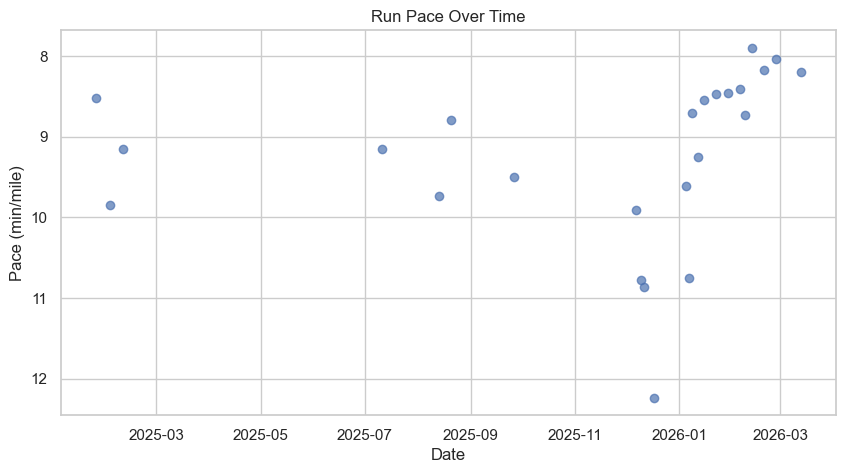

In [38]:
plt.figure(figsize=(10,5))

plt.scatter(runs["date"], runs["pace_min_per_mile"], alpha=0.7)

plt.gca().invert_yaxis()  # faster paces appear higher
plt.title("Run Pace Over Time")
plt.xlabel("Date")
plt.ylabel("Pace (min/mile)")

plt.show()

## **_Distance Distribution_**

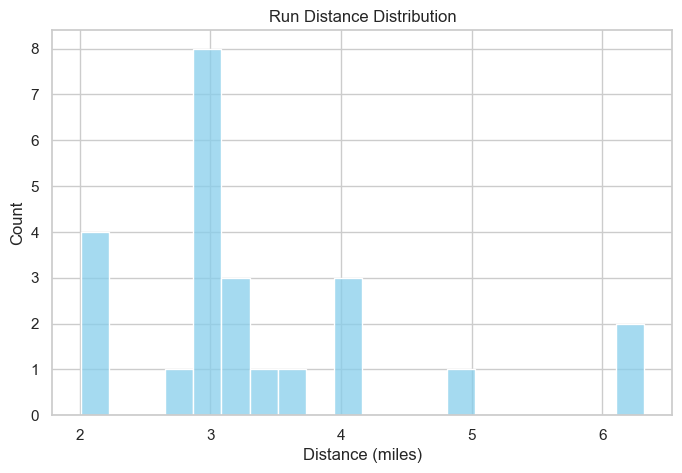

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(runs["distance_miles"], bins=20, kde=False, color='skyblue')

plt.title("Run Distance Distribution")
plt.xlabel("Distance (miles)")
plt.ylabel("Count")

plt.show()

## **_Weekly Mileage_**

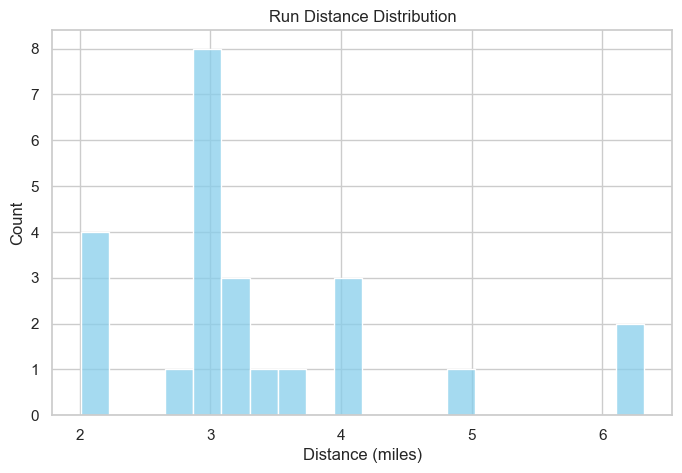

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(runs["distance_miles"], bins=20, kde=False, color='skyblue')

plt.title("Run Distance Distribution")
plt.xlabel("Distance (miles)")
plt.ylabel("Count")

plt.show()

## **_Pace vs Distance_**

In [41]:
import plotly.express as px

fig = px.scatter(
    runs,
    x="distance_miles",
    y="pace_min_per_mile",
    size="distance_miles",
    color="Long Run",
    hover_data=["date", "Activity Name"],
    title="Pace vs Distance (Interactive)"
)

fig.update_yaxes(autorange="reversed")  # faster paces on top
fig.show()

In [42]:
# quick check of data quality
# Check for missing values
print("Missing values per column:\n", runs.isna().sum())

# Summary statistics
runs.describe()

Missing values per column:
 date                    0
Activity Name           0
Activity Type           0
distance_m              0
moving_time_s           0
elapsed_time_s          0
avg_speed               0
max_speed               0
elev_gain               0
elev_loss               0
Average Grade           0
Max Grade               0
avg_hr                 24
max_hr                 24
Relative Effort        24
Perceived Exertion     24
Training Load           3
Intensity               3
Weather Temperature    22
Humidity               22
Wind Speed             22
Commute                 0
Long Run               24
Competition            24
distance_miles          0
time_min                0
pace_min_per_mile       0
dtype: int64


,date,distance_m,moving_time_s,elapsed_time_s,avg_speed,max_speed,elev_gain,elev_loss,Average Grade,Max Grade,...,Training Load,Intensity,Weather Temperature,Humidity,Wind Speed,Long Run,Competition,distance_miles,time_min,pace_min_per_mile
count,24,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,...,21.000000,21.000000,2.000000,2.000000,2.000000,0.0,0.0,24.000000,24.000000,24.000000
mean,2025-11-10 06:02:40.125000,5.435833,1885.208333,1965.291667,2.940958,4.815250,31.850000,35.066667,-0.070833,8.808333,...,124.142857,154.333333,24.300000,0.830000,1.100000,NaN,NaN,3.377669,31.420139,9.237284
min,2025-01-24 17:24:29,3.230000,1051.000000,1154.000000,2.192000,3.500000,0.000000,0.000000,-0.700000,0.000000,...,72.000000,134.000000,23.600000,0.810000,0.900000,NaN,NaN,2.007028,17.516667,7.897093
25%,2025-09-17 05:11:12.500000,4.830000,1492.000000,1495.750000,2.750500,4.230000,15.550000,17.000000,-0.100000,5.600000,...,105.000000,146.000000,23.950000,0.820000,1.000000,NaN,NaN,3.001222,24.866667,8.464042
50%,2026-01-05 17:38:16,4.900000,1625.500000,1627.000000,2.995000,4.630000,20.800000,19.100000,0.000000,7.850000,...,113.000000,157.000000,24.300000,0.830000,1.100000,NaN,NaN,3.044718,27.091667,8.974138
75%,2026-01-31 06:31:52.500000,5.957500,2426.250000,2517.750000,3.169750,5.020000,42.900000,53.650000,0.000000,11.825000,...,128.000000,162.000000,24.650000,0.840000,1.200000,NaN,NaN,3.701818,40.437500,9.764337
max,2026-03-12 20:30:08,10.170000,3506.000000,3711.000000,3.398000,8.241000,99.200000,110.400000,0.200000,28.300000,...,235.000000,172.000000,25.000000,0.850000,1.300000,NaN,NaN,6.319343,58.433333,12.235145
std,NaN,1.826648,699.977887,765.735252,0.313176,1.037733,27.979573,31.135645,0.180529,6.039142,...,48.117861,10.465817,0.989949,0.028284,0.282843,NaN,NaN,1.135026,11.666298,1.076070


## **_Performance Curve_**

In [43]:
# round distance to nearest 0.5 mile
runs["distance_bin"] = runs["distance_miles"].round(1)

# groups by distance bin and find fastest pace
fastest_pace = runs.groupby("distance_bin")["pace_min_per_mile"].min().reset_index()

fastest_pace.head()

,distance_bin,pace_min_per_mile
0,2.0,8.797750
1,2.1,8.516722
2,2.8,9.908724
3,3.0,7.897093
4,3.1,8.035972


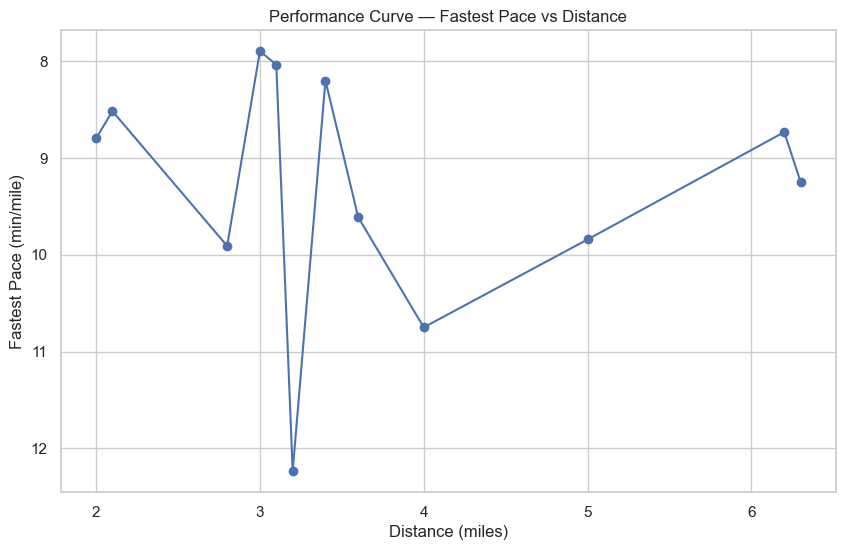

In [44]:
plt.figure(figsize=(10,6))

plt.plot(fastest_pace["distance_bin"], fastest_pace["pace_min_per_mile"], marker='o', linestyle='-')

plt.gca().invert_yaxis()  # faster paces appear higher
plt.title("Performance Curve — Fastest Pace vs Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Fastest Pace (min/mile)")
plt.grid(True)
plt.show()

# **Export Data to CSV for model prediction**

In [ ]:
os.makedirs("../data", exist_ok=True)

#export data
export_path = "../data/runs_cleaned_data.csv"
runs.to_csv(export_path, index=False)

print(f"Cleaned run data saved to {export_path}")